# Based on runs in project `v40` (before input feature centering)

## References and Regressors only

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
# Set plotting font size
plt.rcParams["font.size"] = 12

from pathlib import Path

base_model = pd.read_csv(
    Path(os.getcwd()).parent / "eval_newmech/EGFR_MAPK/dream_cytof/evaluate_all.csv"
).assign(model="EGFR_MAPK")
egfr_model = pd.read_csv(
    Path(os.getcwd()).parent / "eval_newmech/EGFR_MAPK_tegfr/dream_cytof/evaluate_all.csv"
).assign(model="EGFR_MAPK_tegfr")

all_df = pd.concat(
    [egfr_model, base_model], ignore_index=True
)

all_df.drop(columns=["Unnamed: 0"], inplace=True)
all_df["features"].fillna("None", inplace=True)

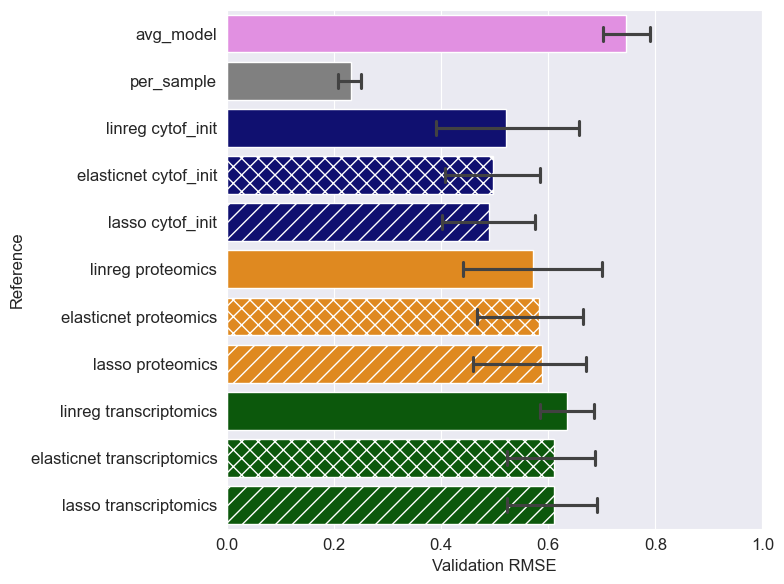

In [2]:
# Filter
df = all_df[
    (all_df.dataset == "val") &
    (all_df.model == "EGFR_MAPK") &
    (all_df.ref != "DMM")
].copy()

# Construct grouped labels
def make_label(row):
    if row["ref"] == "avg_model":
        return "avg_model"
    elif row["ref"] == "sample":
        return "per_sample"
    else:
        return f"{row['ref']} {row['context']}"

df["grouped_ref"] = df.apply(make_label, axis=1)

# Extract plotting components
order = [
    "avg_model",
    "per_sample",
    "linreg cytof_init", "elasticnet cytof_init", "lasso cytof_init",
    "linreg proteomics", "elasticnet proteomics", "lasso proteomics",
    "linreg transcriptomics", "elasticnet transcriptomics", "lasso transcriptomics"
]
df["grouped_ref"] = pd.Categorical(df["grouped_ref"], categories=order, ordered=True)

# Summary RMSE per method
summary = df.groupby("grouped_ref", sort=False)["rmse"].mean().reset_index()

# Define fill logic
def get_hatch(ref):
    if "elasticnet" in ref:
        return 'xx'
    elif "lasso" in ref:
        return '//'
    else:
        return ''  # linreg or avg_model/per_sample

def get_color(ref):
    if "cytof_init" in ref:
        return "navy"
    elif "proteomics" in ref:
        return "darkorange"
    elif "transcriptomics" in ref:
        return "darkgreen"
    elif "avg_model" in ref:
        return "violet"
    elif "per_sample" in ref:
        return "gray"
    else:
        return "black"

hatches = [get_hatch(ref) for ref in order]
colors = [get_color(ref) for ref in order]

# Plot
plt.rcParams["font.size"] = 12
fig, ax = plt.subplots(figsize=(8, 6))
bars = sns.barplot(data=df, x="rmse", y="grouped_ref", ax=ax, palette=colors, capsize=0.3)

# Apply hatching
for bar, hatch in zip(bars.patches[::-1], hatches[::-1]):
    bar.set_hatch(hatch)

# Final touches
ax.set_xlim(0, 1)
ax.set_xlabel("Validation RMSE", fontsize=12)
ax.set_ylabel("Reference", fontsize=12)
plt.tight_layout()
# plt.savefig("baselines_barplot_v40.svg")
plt.show()

## Compare DMMs with references and regressors across models

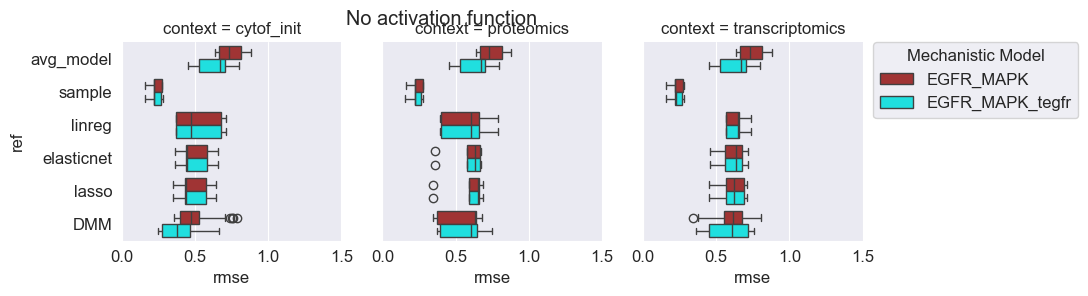

In [3]:
g = sns.FacetGrid(
    all_df[
        (all_df.dataset == "val") &
        ((all_df.ref != "DMM") | (all_df.last_layer_activation == False))
    ],
    # row="samples",
    # row_order=[f"{i}of5" for i in range(5)],
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics"],
)

g.map_dataframe(
    sns.boxplot,
    x="rmse",
    y="ref",
    hue="model",
    hue_order=["EGFR_MAPK", "EGFR_MAPK_tegfr"],
    palette={"EGFR_MAPK": "firebrick", "EGFR_MAPK_tegfr": "cyan"},
    order=["avg_model", "sample", "linreg", "elasticnet", "lasso", "DMM"],
)

# Set x-axis limits for each subplot
for ax in g.axes.flat:
    ax.set_xlim(0, 1.50)

plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title='Mechanistic Model')
plt.suptitle("No activation function")
plt.show()

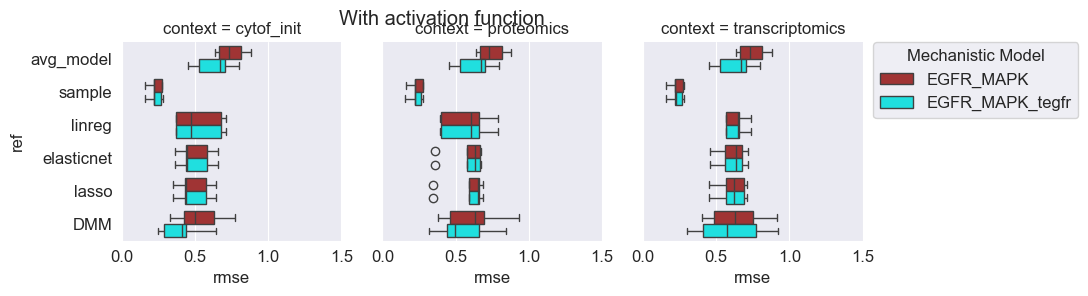

In [4]:
g = sns.FacetGrid(
    all_df[
        (all_df.dataset == "val") &
        ((all_df.ref != "DMM") | (all_df.last_layer_activation == True))
    ],
    # row="samples",
    # row_order=[f"{i}of5" for i in range(5)],
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics"],
)

g.map_dataframe(
    sns.boxplot,
    x="rmse",
    y="ref",
    hue="model",
    hue_order=["EGFR_MAPK", "EGFR_MAPK_tegfr"],
    palette={"EGFR_MAPK": "firebrick", "EGFR_MAPK_tegfr": "cyan"},
    order=["avg_model", "sample", "linreg", "elasticnet", "lasso", "DMM"],
)

# Set x-axis limits for each subplot
for ax in g.axes.flat:
    ax.set_xlim(0, 1.50)

plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title='Mechanistic Model')
plt.suptitle("With activation function")
plt.show()

In [5]:
# Since we will be subsetting to no activation function, fill missing values for baselines and regressors with False
all_df["last_layer_activation"].fillna(False, inplace=True)

# EGFR_MAPK

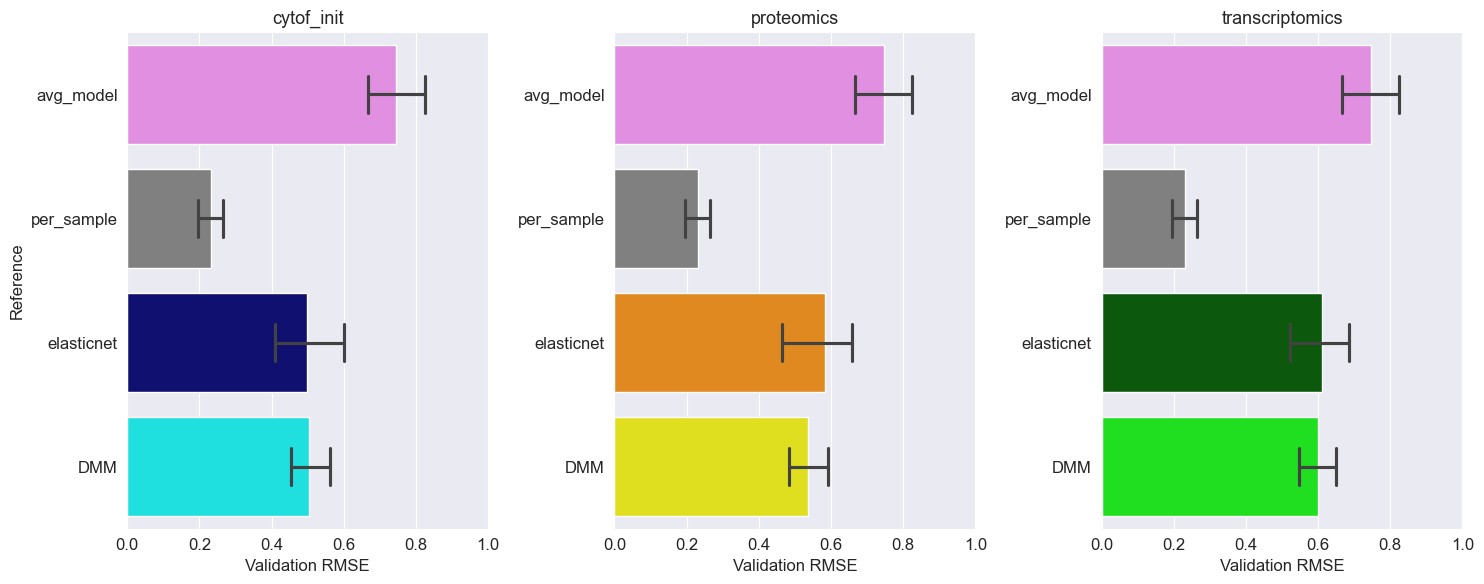

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter
df = all_df[
    (all_df.dataset == "val") &
    (all_df.model == "EGFR_MAPK") &
    (all_df.last_layer_activation == False)
].copy()

# Only keep relevant refs
df = df[df["ref"].isin(["avg_model", "sample", "elasticnet", "DMM"])]
df["grouped_ref"] = df["ref"].replace({"sample": "per_sample"})

# Define bar order per context
ref_order = ["avg_model", "per_sample", "elasticnet", "DMM"]

# Define color mapping per context
context_color_map = {
    "cytof_init": {
        "elasticnet": "navy",
        "DMM": "cyan"
    },
    "proteomics": {
        "elasticnet": "darkorange",
        "DMM": "yellow"
    },
    "transcriptomics": {
        "elasticnet": "darkgreen",
        "DMM": "lime"
    }
}

default_colors = {
    "avg_model": "violet",
    "per_sample": "gray"
}

def get_color(row):
    ctx = row["context"]
    ref = row["grouped_ref"]
    return context_color_map.get(ctx, {}).get(ref, default_colors.get(ref, "black"))

df["color"] = df.apply(get_color, axis=1)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True)

for ax, context in zip(axes, ["cytof_init", "proteomics", "transcriptomics"]):
    data_c = df[df["context"] == context]
    data_c["grouped_ref"] = pd.Categorical(data_c["grouped_ref"], categories=ref_order, ordered=True)
    bars = sns.barplot(
        data=data_c,
        x="rmse",
        y="grouped_ref",
        order=ref_order,
        palette=data_c.set_index("grouped_ref")["color"].to_dict(),
        ax=ax,
        capsize=0.3
    )

    ax.set_title(context, fontsize=13)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Validation RMSE")
    if ax == axes[0]:
        ax.set_ylabel("Reference")
    else:
        ax.set_ylabel("")

plt.tight_layout()
# plt.savefig("contextwise_barplot_with_DMM.png")
plt.show()

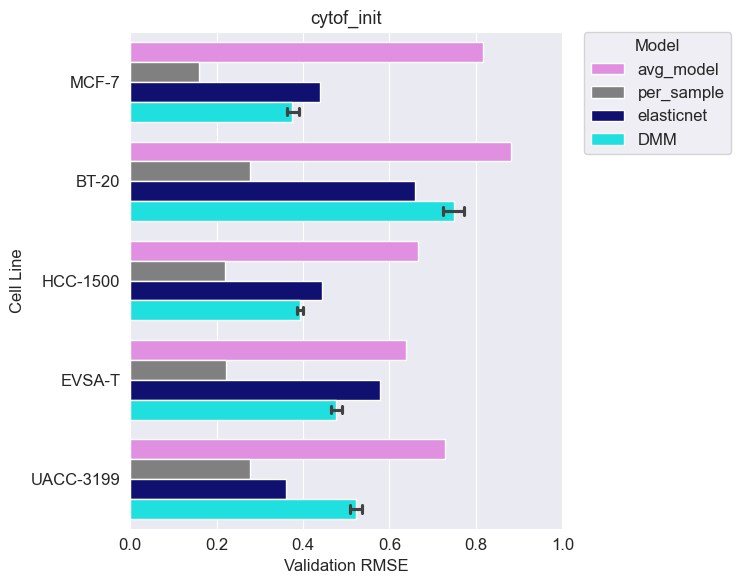

In [7]:
# Define mapping from CV splits to validation cell-line names
sample_label_map = {
    "0of5": "MCF-7",
    "1of5": "BT-20",
    "2of5": "HCC-1500",
    "3of5": "EVSA-T",
    "4of5": "UACC-3199"
}

# Apply mapping before plotting
df["sample_label"] = df["samples"].map(sample_label_map)

data_c = df[df["context"] == "cytof_init"].copy()
data_c["sample_label"] = pd.Categorical(data_c["sample_label"], categories=sample_label_map.values(), ordered=True)

plt.figure(figsize=(6, 6))
bars = sns.barplot(
    data=data_c.sort_values(by="sample_label"),
    x="rmse",
    y="sample_label",
    hue="grouped_ref",
    hue_order=ref_order,
    palette=data_c.set_index("grouped_ref")["color"].to_dict(),
    capsize=0.3
)

ax = plt.gca()
ax.set_title("cytof_init", fontsize=13)
ax.set_xlim(0, 1)
ax.set_xlabel("Validation RMSE")
ax.set_ylabel("Cell Line")

plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Model")
# plt.savefig("contextwise_barplot_with_DMM_cytof_samples_labeled.svg")
plt.show()

## Model comparison: EGFR_MAPK vs EGFR_MAPK_tegfr

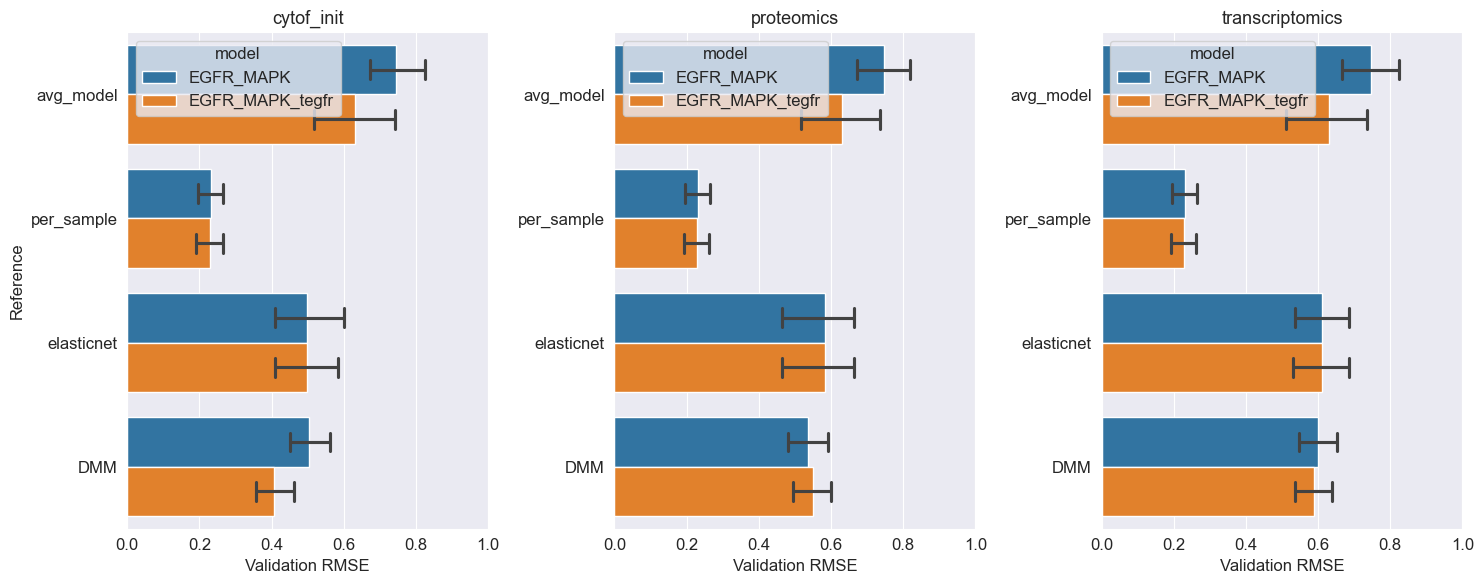

In [8]:
# Filter
df = all_df[
    (all_df.dataset == "val")
    &
    (all_df.last_layer_activation == False)
].copy()

# Only keep relevant refs
df = df[df["ref"].isin(["avg_model", "sample", "elasticnet", "DMM"])]
df["grouped_ref"] = df["ref"].replace({"sample": "per_sample"})
df["color"] = df.apply(get_color, axis=1)

# Define bar order per context
ref_order = ["avg_model", "per_sample", "elasticnet", "DMM"]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True)
for ax, context in zip(axes, ["cytof_init", "proteomics", "transcriptomics"]):
    data_c = df[df["context"] == context]
    data_c["grouped_ref"] = pd.Categorical(data_c["grouped_ref"], categories=ref_order, ordered=True)
    bars = sns.barplot(
        data=data_c,
        x="rmse",
        y="grouped_ref",
        order=ref_order,
        hue="model",
        hue_order=["EGFR_MAPK", "EGFR_MAPK_tegfr"],
        ax=ax,
        capsize=0.3
    )

    ax.set_title(context, fontsize=13)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Validation RMSE")
    if ax == axes[0]:
        ax.set_ylabel("Reference")
    else:
        ax.set_ylabel("")

plt.tight_layout()
# plt.savefig("contextwise_barplot_with_DMM_modelcomp.svg")
plt.show()

## Zoom-in on cytof_init, EGFR_MAPK_tEGFR to check on per-CV-split performance

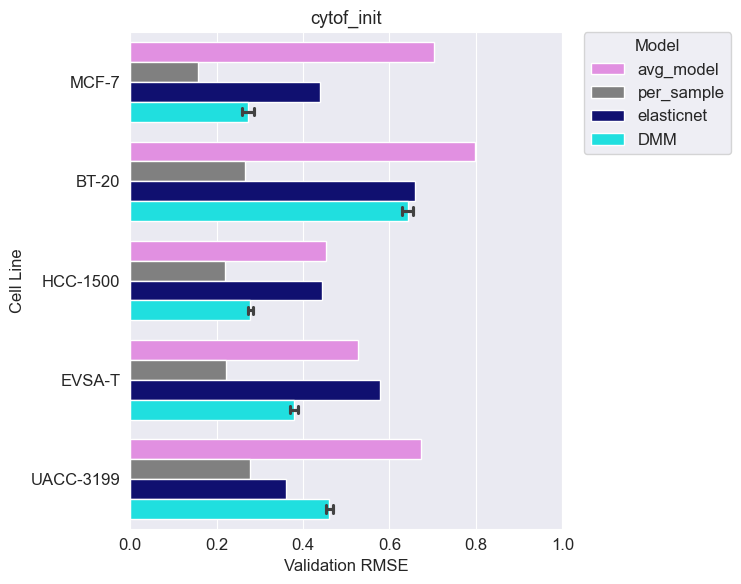

In [9]:
# Filter
df = all_df[
    (all_df.dataset == "val")
    &
    (all_df.last_layer_activation == False)
    &
    (all_df.model == "EGFR_MAPK_tegfr")
].copy()

df["grouped_ref"] = df["ref"].replace({"sample": "per_sample"})
df["color"] = df.apply(get_color, axis=1)

# Apply mapping before plotting
df["sample_label"] = df["samples"].map(sample_label_map)

# Now use the mapped column for y-axis
plt.figure(figsize=(6, 6))
data_c = df[df["context"] == "cytof_init"].copy()
data_c["sample_label"] = pd.Categorical(data_c["sample_label"], categories=sample_label_map.values(), ordered=True)

bars = sns.barplot(
    data=data_c.sort_values(by="sample_label"),
    x="rmse",
    y="sample_label",
    hue="grouped_ref",
    hue_order=ref_order,
    palette=data_c.set_index("grouped_ref")["color"].to_dict(),
    capsize=0.3
)

ax = plt.gca()
ax.set_title("cytof_init", fontsize=13)
ax.set_xlim(0, 1)
ax.set_xlabel("Validation RMSE")
ax.set_ylabel("Cell Line")

plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Model")
# plt.savefig("contextwise_barplot_with_DMM_cytof_samples_labeled_tegfr.svg")
plt.show()

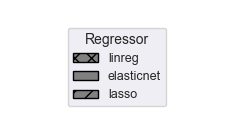

In [10]:
from matplotlib.patches import Patch

# Define each regressor's style
legend_elements = [
    Patch(facecolor='gray', edgecolor='black', label='linreg', hatch='xx'),
    Patch(facecolor='gray', edgecolor='black', label='elasticnet', hatch=''),
    Patch(facecolor='gray', edgecolor='black', label='lasso', hatch='//'),
]

# Create a standalone legend figure
fig, ax = plt.subplots(figsize=(2.5, 1.5))
ax.axis('off')  # No axes, just legend

legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,
    title='Regressor',
    title_fontsize=10,
    fontsize=9
)

plt.tight_layout()
# plt.savefig("regressor_hatch_legend.svg", format="svg")
plt.show()